Loading data...
Train shape: (590540, 434)
Test shape: (506691, 433)
Feature engineering...
Categorical features: 16
Using 394 common features

Starting 3-Fold Cross Validation...

Fold 1/3


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 100 rounds
[50]	train's auc: 0.919918	valid's auc: 0.913534
[100]	train's auc: 0.937797	valid's auc: 0.927026
[150]	train's auc: 0.947836	valid's auc: 0.934355
[200]	train's auc: 0.955142	valid's auc: 0.939514
[250]	train's auc: 0.959175	valid's auc: 0.94223
[300]	train's auc: 0.964111	valid's auc: 0.94488
[350]	train's auc: 0.968346	valid's auc: 0.94794
[400]	train's auc: 0.971753	valid's auc: 0.950458
[450]	train's auc: 0.974831	valid's auc: 0.952307
[500]	train's auc: 0.976911	valid's auc: 0.953671
[550]	train's auc: 0.978981	valid's auc: 0.955077
[600]	train's auc: 0.980783	valid's auc: 0.956109
[650]	train's auc: 0.982535	valid's auc: 0.957224
[700]	train's auc: 0.984207	valid's auc: 0.958356
[750]	train's auc: 0.985746	valid's auc: 0.95954
[800]	train's auc: 0.987007	valid's auc: 0.960374
[850]	train's auc: 0.988176	valid's auc: 0.961187
[900]	train's auc: 0.989174	valid's auc: 0.961744
[950]	train's auc: 0.990187	valid's auc: 0.

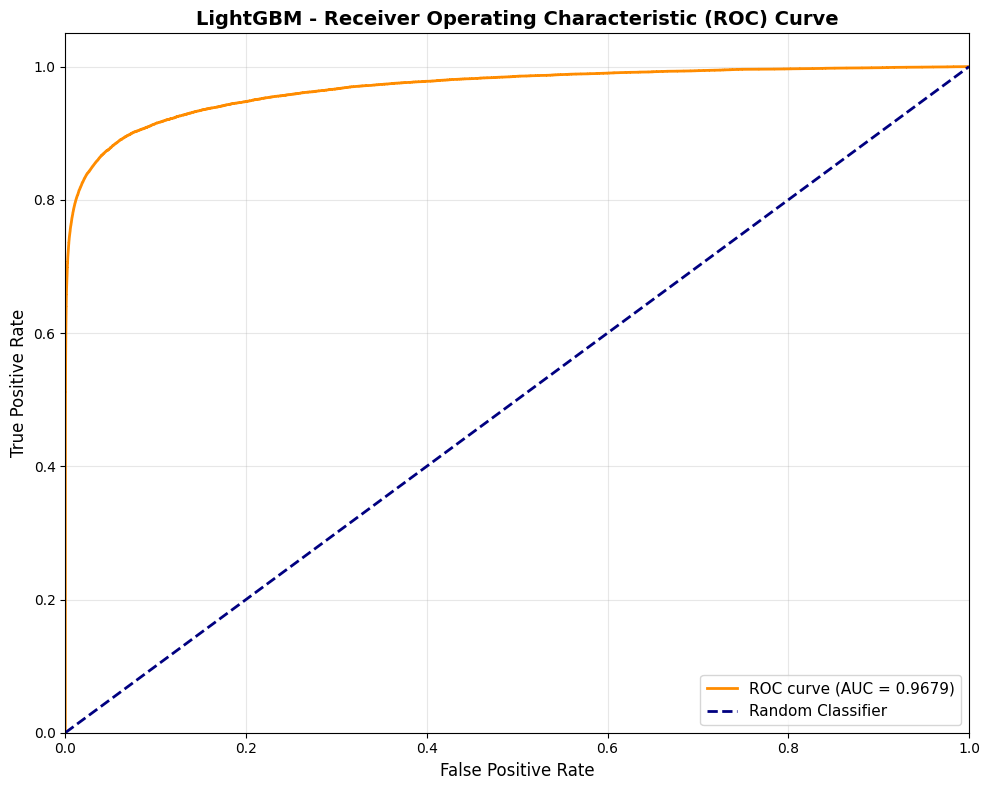

ROC curve saved: roc_curve.png

GENERATING CONFUSION MATRIX
Optimal threshold (Youden's J): 0.0201


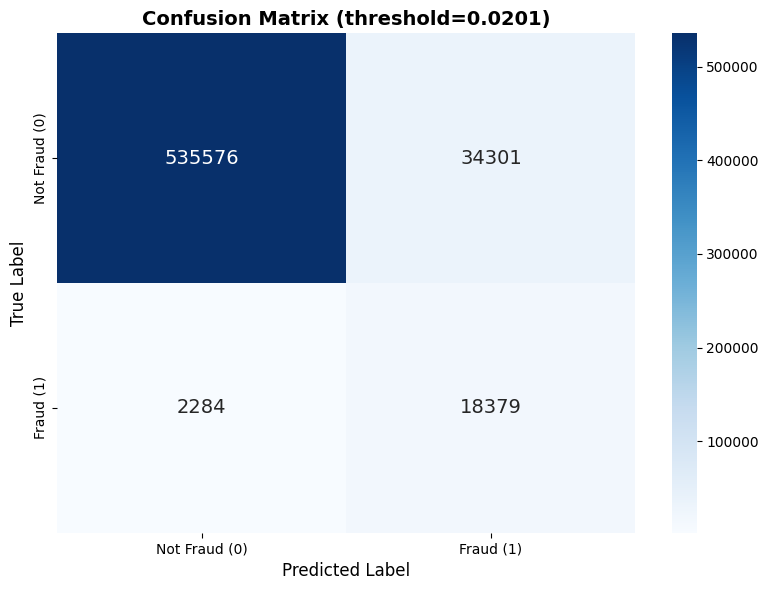

Confusion matrix saved: confusion_matrix.png

CONFUSION MATRIX BREAKDOWN
True Negatives:  535,576
False Positives: 34,301
False Negatives: 2,284
True Positives:  18,379

Precision:    0.3489
Recall:       0.8895
F1-Score:     0.5012
Specificity:  0.9398

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Not Fraud       1.00      0.94      0.97    569877
       Fraud       0.35      0.89      0.50     20663

    accuracy                           0.94    590540
   macro avg       0.67      0.91      0.73    590540
weighted avg       0.97      0.94      0.95    590540


CREATING SUBMISSION FILE
Submission file created: submission.csv

Submission Statistics:
  Total predictions: 506,691
  Predictions range: [0.000000, 0.999996]
  Mean prediction: 0.023567
  Median prediction: 0.000676
  Predicted fraud rate (threshold=0.5): 0.0176
  Predicted fraud rate (optimal threshold=0.0201): 0.0889

First 10 predictions:
   TransactionID   isFraud
0        3663549  0.00

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')
test_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

target = train['isFraud']
train_id = train['TransactionID']
test_id = test['TransactionID']

# Drop target and ID columns
train = train.drop(['isFraud', 'TransactionID'], axis=1)
test = test.drop(['TransactionID'], axis=1)

print("Feature engineering...")

# Memory optimization
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

# Handle categorical features
cat_features = [col for col in train.columns if train[col].dtype == 'object' and col in test.columns]
print(f"Categorical features: {len(cat_features)}")

for col in cat_features:
    train[col] = train[col].fillna('unknown')
    test[col] = test[col].fillna('unknown')
    
    # Combine train and test for consistent encoding
    combined = pd.concat([train[col], test[col]], axis=0)
    train[col] = pd.Categorical(combined).codes[:len(train)]
    test[col] = pd.Categorical(combined).codes[len(train):]

# Ensure train and test have the same columns
common_cols = list(set(train.columns) & set(test.columns))
train = train[common_cols]
test = test[common_cols]
print(f"Using {len(common_cols)} common features")

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'num_leaves': 128,
    'learning_rate': 0.05,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': 8,
    'min_child_samples': 100,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'seed': 42,
    'max_bin': 63
}

# K-Fold Cross Validation
n_folds = 3
folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
feature_importance_df = pd.DataFrame()

print(f"\nStarting {n_folds}-Fold Cross Validation...")

for fold, (train_idx, val_idx) in enumerate(folds.split(train, target)):
    print(f"\n{'='*50}")
    print(f"Fold {fold + 1}/{n_folds}")
    print(f"{'='*50}")
    
    X_train, X_val = train.iloc[train_idx], train.iloc[val_idx]
    y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]
    
    # Create LightGBM datasets
    lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_features)
    lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=cat_features, reference=lgb_train)
    
    # Train model
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=3000,
        valid_sets=[lgb_train, lgb_val],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=50)
        ]
    )
    
    # Predictions
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(test, num_iteration=model.best_iteration) / n_folds
    
    # Feature importance
    fold_importance = pd.DataFrame()
    fold_importance['feature'] = train.columns
    fold_importance['importance'] = model.feature_importance(importance_type='gain')
    fold_importance['fold'] = fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)
    
    # Calculate fold AUC
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"\nFold {fold + 1} AUC: {fold_auc:.6f}")
    
    del X_train, X_val, y_train, y_val, lgb_train, lgb_val, model
    gc.collect()

# Calculate overall CV AUC
cv_auc = roc_auc_score(target, oof_preds)
print(f"\n{'='*50}")
print(f"Overall CV AUC: {cv_auc:.6f}")
print(f"{'='*50}\n")

# Feature importance analysis
feature_importance_df_agg = feature_importance_df.groupby('feature')['importance'].mean().reset_index()
feature_importance_df_agg = feature_importance_df_agg.sort_values('importance', ascending=False)
print("\nTop 20 Most Important Features:")
print(feature_importance_df_agg.head(20))

# Save feature importance
feature_importance_df_agg.to_csv('feature_importance.csv', index=False)
print("\nFeature importance saved: feature_importance.csv")

# ============================================================================
# ROC CURVE
# ============================================================================
print("\n" + "="*50)
print("GENERATING ROC CURVE")
print("="*50)

fpr, tpr, thresholds = roc_curve(target, oof_preds)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {cv_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('LightGBM - Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROC curve saved: roc_curve.png")

# ============================================================================
# CONFUSION MATRIX
# ============================================================================
print("\n" + "="*50)
print("GENERATING CONFUSION MATRIX")
print("="*50)

# Find optimal threshold using Youden's J statistic
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

# Generate predictions with optimal threshold
oof_preds_binary = (oof_preds >= optimal_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(target, oof_preds_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Fraud (0)', 'Fraud (1)'],
            yticklabels=['Not Fraud (0)', 'Fraud (1)'],
            annot_kws={'size': 14})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix (threshold={optimal_threshold:.4f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved: confusion_matrix.png")

# Print detailed metrics
print("\n" + "="*50)
print("CONFUSION MATRIX BREAKDOWN")
print("="*50)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

# Calculate additional metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nPrecision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"F1-Score:     {f1:.4f}")
print(f"Specificity:  {specificity:.4f}")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(target, oof_preds_binary, target_names=['Not Fraud', 'Fraud']))

# ============================================================================
# CREATE SUBMISSION FILE
# ============================================================================
print("\n" + "="*50)
print("CREATING SUBMISSION FILE")
print("="*50)

submission = pd.DataFrame({
    'TransactionID': test_id,
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)

print("Submission file created: submission.csv")
print(f"\nSubmission Statistics:")
print(f"  Total predictions: {len(test_preds):,}")
print(f"  Predictions range: [{test_preds.min():.6f}, {test_preds.max():.6f}]")
print(f"  Mean prediction: {test_preds.mean():.6f}")
print(f"  Median prediction: {np.median(test_preds):.6f}")
print(f"  Predicted fraud rate (threshold=0.5): {(test_preds > 0.5).mean():.4f}")
print(f"  Predicted fraud rate (optimal threshold={optimal_threshold:.4f}): {(test_preds > optimal_threshold).mean():.4f}")

print("\nFirst 10 predictions:")
print(submission.head(10))

print("\n" + "="*50)
print("ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*50)
print("\nGenerated files:")
print("  1. submission.csv - Kaggle submission file")
print("  2. roc_curve.png - ROC curve visualization")
print("  3. confusion_matrix.png - Confusion matrix heatmap")
print("  4. feature_importance.csv - Feature importance scores")